In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

import warnings
warnings.filterwarnings('ignore')

# EDA-1 (Bike Details Dataset)

In [9]:
bike_df = pd.read_csv("D:\PW\ML\EDA\BIKE DETAILS.csv")

In [15]:
bike_df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

### 1. What is the range of selling prices in the dataset ?

In [18]:
print("Range of selling price is : ",bike_df["selling_price"].min(), " to ", bike_df["selling_price"].max())

Range of selling price is :  5000  to  760000


### 2. What is the median selling price for bikes in the dataset

In [20]:
bike_df["selling_price"].median()

45000.0

### 3. What is the most common seller type

In [21]:
bike_df['seller_type'].value_counts().idxmax()

'Individual'

### 4. How many bikes have driven more than 50,000 kilometers

In [36]:
bike_df[bike_df['km_driven'] > 50000]["km_driven"].count()

170

### 5. What is the average km_driven value for each ownership type

In [42]:
bike_df.groupby('owner')['km_driven'].mean()

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64

### 6. What proportion of bikes are from the year 2015 or older

In [48]:
(bike_df[bike_df["year"]<=2015]["year"].count() / len(bike_df)) * 100

56.64467483506126

### 7 What is the trend of missing values across the dataset

In [52]:
bike_df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

### 8. What is the highest ex_showroom_price recorded, and for which bike


In [57]:
bike_df.loc[bike_df['ex_showroom_price'].idxmax(), ['name', 'ex_showroom_price']]

name                 Harley-Davidson Street Bob
ex_showroom_price                     1278000.0
Name: 134, dtype: object

### 9. What is the total number of bikes listed by each seller type


In [59]:
bike_df['seller_type'].value_counts()

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64

### 10 What is the relationship between selling_price and km_driven for first-owner bikes


In [60]:
first_owner_bikes = bike_df[bike_df['owner'] == '1st owner']
first_owner_bikes[['km_driven', 'selling_price']].corr()

,km_driven,selling_price
km_driven,1.000000,-0.243482
selling_price,-0.243482,1.000000


### 11. Identify and remove outliers in the km_driven column using the IQR method


In [65]:
Q1 = bike_df['km_driven'].quantile(0.25)
Q3 = bike_df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
print("Before remove outliers total rows :  ",bike_df.shape[0])
without_outliers_df = bike_df[~((bike_df['km_driven'] < (Q1 - 1.5 * IQR)) |
                                   (bike_df['km_driven'] > (Q3 + 1.5 * IQR)))]

print("After remove outliers total row:  ",without_outliers_df.shape[0])

Before remove outliers total rows :   1061
After remove outliers total row:   1022


### 12. Perform a bivariate analysis to visualize the relationship between year and selling_price


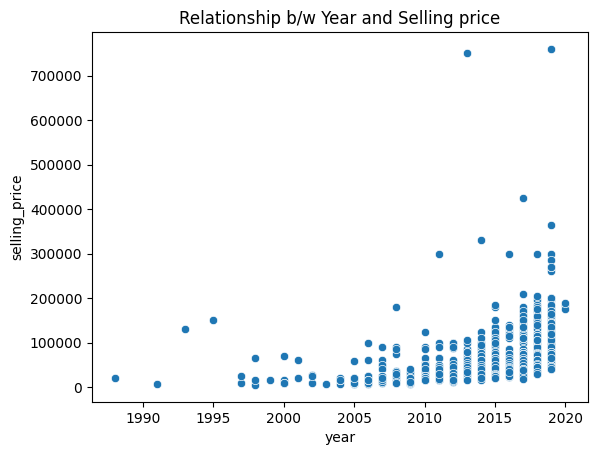

In [67]:
sns.scatterplot(data=bike_df, x='year', y='selling_price')
plt.title('Relationship b/w Year and Selling price') 
plt.show()

### 13. What is the average depreciation in selling price based on the bike's age (current year - manufacturingyear)

In [69]:
current_year = datetime.datetime.now().year
bike_df['bike_age'] = current_year - bike_df['year']
bike_df.groupby('bike_age')['selling_price'].mean()

bike_age
5     183333.333333
6     119689.511628
7      87660.374046
8      78894.736842
9      58469.018692
10     56500.000000
11     48668.131868
12     51136.986301
13     35748.400000
14     35655.721311
15     31793.333333
16     22267.857143
17     34289.285714
18     24927.586207
19     23380.000000
20     16978.571429
21     15100.000000
22      8000.000000
23     20666.666667
24     40000.000000
25     20833.333333
26     15000.000000
27     28333.333333
28     17500.000000
30    150000.000000
32    130000.000000
34      6000.000000
37     20000.000000
Name: selling_price, dtype: float64

### 14. B Which bike names are priced significantly above the average price for their manufacturing year

In [70]:
avg_price_by_year = bike_df.groupby('year')['selling_price'].mean()
high_priced_bikes = bike_df[bike_df.apply(
    lambda row: row['selling_price'] > avg_price_by_year[row['year']], axis=1
)]
high_priced_bikes[['name', 'selling_price', 'year']]

,name,selling_price,year
0,Royal Enfield Classic 350,175000,2019
2,Royal Enfield Classic Gunmetal Grey,150000,2018
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015
7,Royal Enfield Bullet 350 [2007-2011],180000,2008
13,Yamaha YZF R3,365000,2019
...,...,...,...
1004,Bajaj Pulsar NS 200,60000,2016
1005,TVS Apache RTR 160,60000,2014
1008,Bajaj Pulsar 220 F,52000,2012
1012,Bajaj Pulsar NS 200,50000,2014


### 15. Develop a correlation matrix for numeric columns and visualize it using a heatmap.

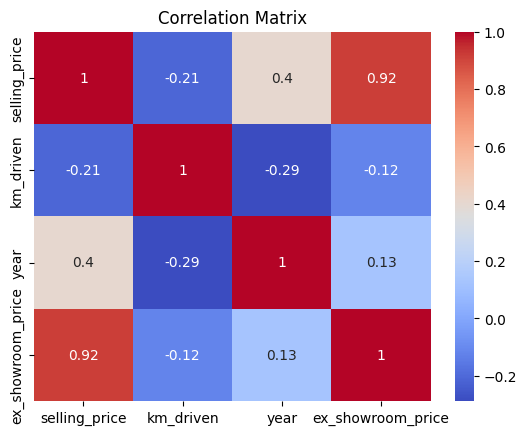

In [71]:
corr_matrix = bike_df[['selling_price', 'km_driven', 'year', 'ex_showroom_price']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# EDA-2 (Car Sale Dataset)

In [72]:
car_df = pd.read_csv("D:\PW\ML\EDA\car sale.csv")

In [77]:
car_df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'price', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [76]:
car_df=car_df.rename(columns={"Price ($)":"price"})

### 1. What is the average selling price of cars for each dealer, and how does it compare across different dealers


In [79]:
car_df.groupby("Dealer_Name")["price"].mean().sort_values(ascending=False)

Dealer_Name
U-Haul CO                                          28769.919006
Classic Chevy                                      28602.014446
Rabun Used Car Sales                               28527.536177
Iceberg Rentals                                    28522.958533
Enterprise Rent A Car                              28312.580800
Scrivener Performance Engineering                  28297.371589
Gartner Buick Hyundai Saab                         28247.621019
Saab-Belle Dodge                                   28190.139888
Capitol KIA                                        28189.703822
Race Car Help                                      28163.372706
Chrysler of Tri-Cities                             28123.091054
Star Enterprises Inc                               28113.055244
Suburban Ford                                      28112.206758
C & M Motors Inc                                   28111.755200
Tri-State Mack Inc                                 28095.562050
Pars Auto Sales             

### 2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends

In [82]:
car_df.groupby('Company')['price'].agg(['min', 'max', 'mean']).assign(price_range=lambda x: x['max'] - x['min'])

,min,max,mean,price_range
Company,,,,
Acura,14000,45501,24758.561684,31501
Audi,12000,85500,22851.790598,73500
BMW,9000,69500,25090.622785,60500
Buick,12000,62801,33634.362187,50801
Cadillac,13000,85800,40972.093558,72800
Chevrolet,10000,82800,26198.606377,72800
Chrysler,12000,51800,26019.529464,39800
Dodge,10000,60851,26406.341113,50851
Ford,1200,69600,29263.682156,68400


### 3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare

<Axes: xlabel='Transmission', ylabel='price'>

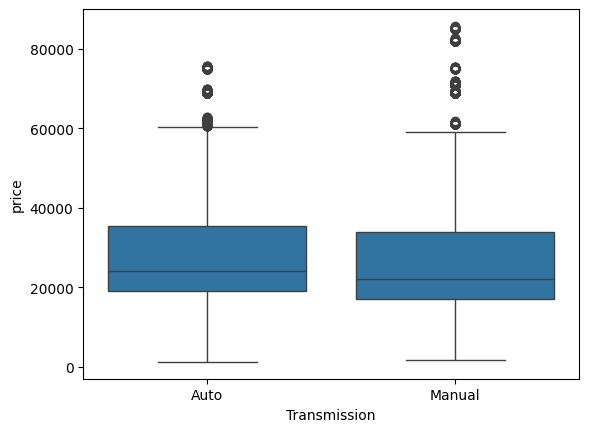

In [84]:
sns.boxplot(data=car_df, x='Transmission', y='price')

### 4. What is the distribution of car prices across different regions

<Axes: title={'center': 'price'}, xlabel='Dealer_Region'>

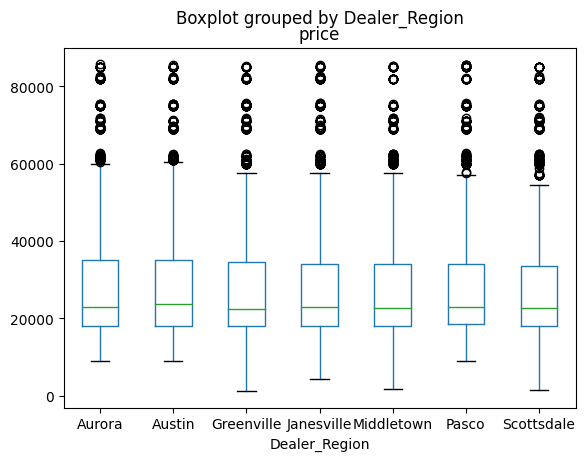

In [85]:
car_df.boxplot(column='price', by='Dealer_Region', grid=False)

### 5. What is the distribution of cars based on body styles

In [86]:
car_df['Body Style'].value_counts()

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64

### 6. How does the average selling price of cars vary by customer gender and annual income

In [88]:
car_df.groupby('Gender').agg({'price': 'mean', 'Annual Income': 'mean'})

,price,Annual Income
Gender,,
Female,28277.265270,755973.021339
Male,28039.429407,851184.044207


### 7. What is the distribution of car prices by region, and how does the number of cars sold vary by region

<Axes: xlabel='Dealer_Region'>

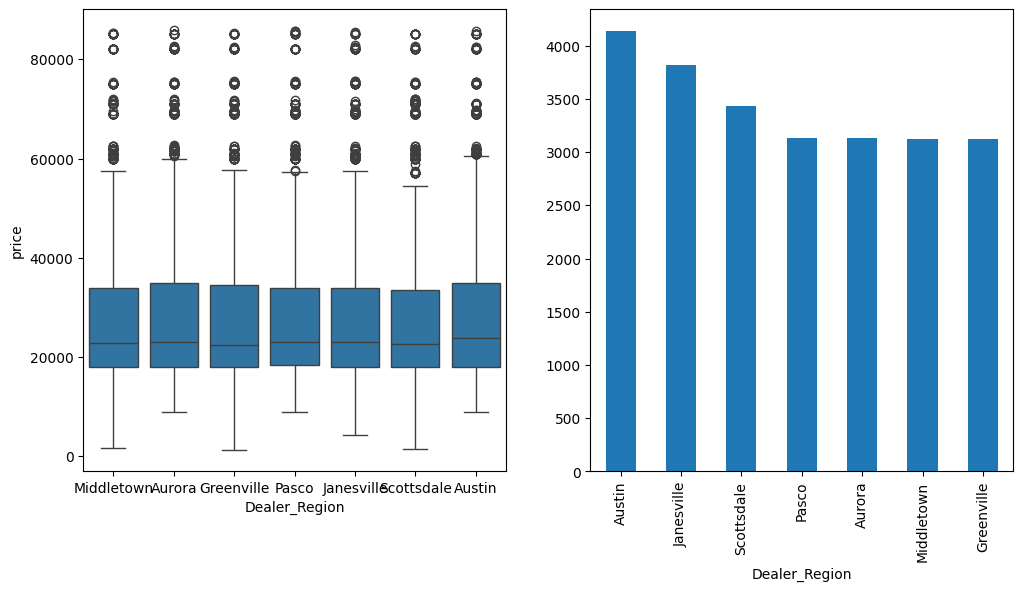

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(data=car_df, x='Dealer_Region', y='price', ax=ax[0])
car_df['Dealer_Region'].value_counts().plot(kind='bar', ax=ax[1])

### 8. How does the average car price differ between cars with different engine sizes

In [94]:
car_df.groupby('Engine')['price'].mean().sort_values(ascending=False)

Engine
DoubleÂ Overhead Camshaft    28248.525972
Overhead Camshaft            27914.710631
Name: price, dtype: float64

### 9. How do car prices vary based on the customer’s annual income bracket

In [95]:
income_bins = [0, 30000, 60000, 100000, 150000, float('inf')]
income_labels = ['0-30k', '30k-60k', '60k-100k', '100k-150k', '150k+']
car_df['Income_Bracket'] = pd.cut(car_df['Annual Income'], bins=income_bins, labels=income_labels)
car_df.groupby('Income_Bracket')['price'].mean()

Income_Bracket
0-30k        27884.297820
30k-60k               NaN
60k-100k     43000.000000
100k-150k    23200.200000
150k+        28149.089557
Name: price, dtype: float64

### 10. What are the top 5 car models with the highest number of sales, and how does their price distribution lookE


<Axes: xlabel='Model', ylabel='price'>

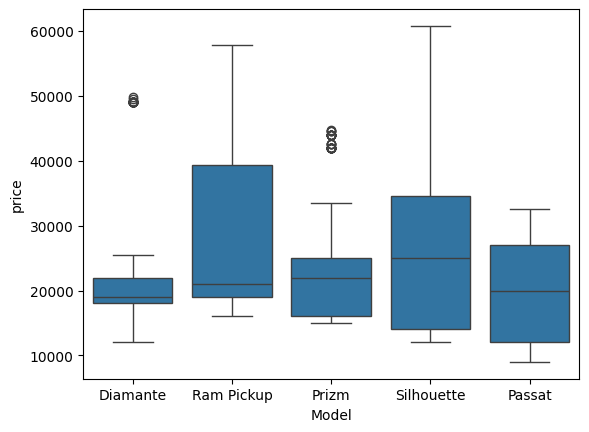

In [96]:
top_5_models = car_df['Model'].value_counts().head(5).index
sns.boxplot(data=car_df[car_df['Model'].isin(top_5_models)], x='Model', y='price')

### 11. How does car price vary with engine size across different car colors, and which colors have the highest price variation

Color
Red           15519.360962
Black         15286.065976
Pale White    14077.346859
Name: price, dtype: float64

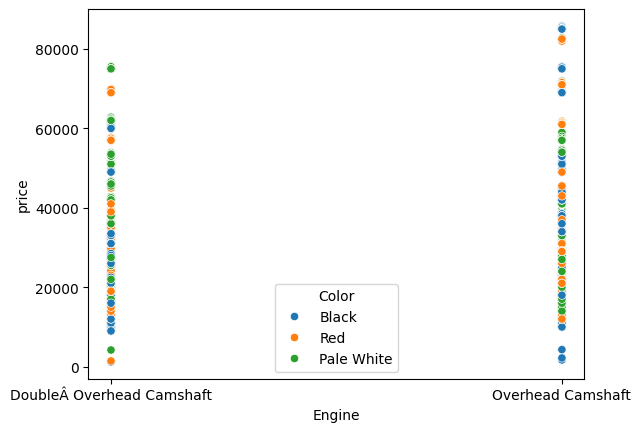

In [97]:
sns.scatterplot(data=car_df, x='Engine', y='price', hue='Color')
car_df.groupby('Color')['price'].std().sort_values(ascending=False)

### 12. Is there any seasonal trend in car sales based on the date of sale

<Axes: title={'center': 'Car Sales by Month'}, xlabel='Sale_Month'>

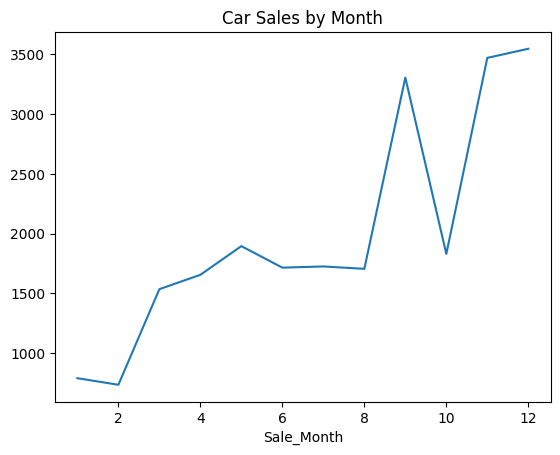

In [98]:
car_df['Sale_Month'] = pd.to_datetime(car_df['Date']).dt.month
car_df.groupby('Sale_Month').size().plot(kind='line', title="Car Sales by Month")

### 13. How does the car price distribution change when considering different combinations of body style and transmission type

<Axes: xlabel='Body Style', ylabel='price'>

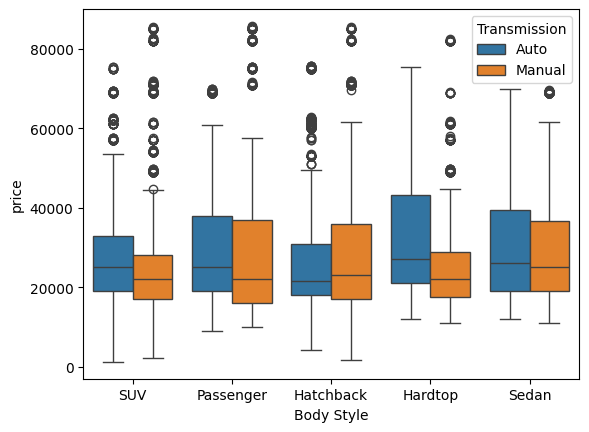

In [99]:
sns.boxplot(data=car_df, x='Body Style', y='price', hue='Transmission')

### 14. What is the correlation between car price, engine size, and annual income of customers, and how do these features interact

price             int64
Engine           object
Annual Income     int64
dtype: object
                  price  Annual Income
price          1.000000       0.012065
Annual Income  0.012065       1.000000


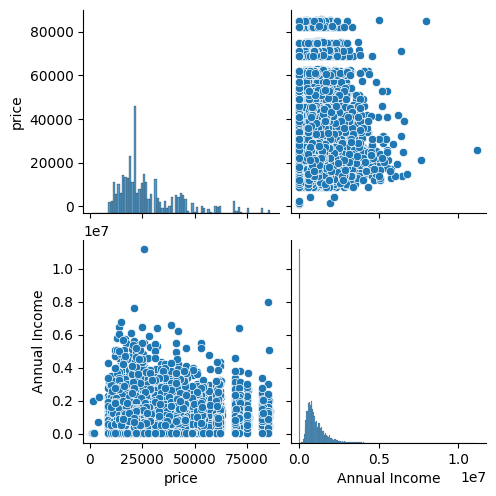

In [102]:
print(car_df[['price', 'Engine', 'Annual Income']].dtypes)
correlation_matrix = car_df[['price', 'Annual Income']].corr()
print(correlation_matrix)
sns.pairplot(car_df[['price', 'Annual Income']])

### 15. How does the average car price vary across different car models and engine types

In [107]:
car_df['Engine'] = car_df['Engine'].str.replace('Â', '', regex=False).str.strip()
avg_price_by_model_engine = car_df.groupby(['Model', 'Engine'])['price'].mean().reset_index()
avg_price_by_model_engine_sorted = avg_price_by_model_engine.sort_values(by='price', ascending=False)
avg_price_by_model_engine_sorted.head(10)

,Model,Engine,price
212,SC,Overhead Camshaft,61074.818182
198,Ranger,Double Overhead Camshaft,61064.055556
222,Sable,Overhead Camshaft,61039.770833
56,Catera,Double Overhead Camshaft,56836.933333
143,LX470,Overhead Camshaft,54037.490196
139,LS400,Overhead Camshaft,53157.941558
111,GS400,Overhead Camshaft,53086.000000
239,Tacoma,Double Overhead Camshaft,53085.821918
25,Aurora,Overhead Camshaft,51833.556962
173,Park Avenue,Double Overhead Camshaft,49387.750000


# EDA-3 (Amazon sales dataset)

In [120]:
amazon_df = pd.read_csv(r'D:\PW\ML\EDA\amazon.csv')

In [121]:
amazon_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [125]:
amazon_df.size

24905

In [122]:
# Cleaning Data
def clean_price(value):
    return pd.to_numeric(value.replace('₹', '').replace(',', '').strip(), errors='coerce')

amazon_df['discounted_price'] = amazon_df['discounted_price'].apply(clean_price)
amazon_df['actual_price'] = amazon_df['actual_price'].apply(clean_price)
amazon_df['discount_percentage'] = amazon_df['discount_percentage'].str.replace('%', '').astype(float)
amazon_df['rating'] = pd.to_numeric(amazon_df['rating'], errors='coerce')
amazon_df['rating_count'] = amazon_df['rating_count'].str.replace(',', '').astype(float)

# Extract top-level category
amazon_df['main_category'] = amazon_df['category'].str.split('|').str[0]

amazon_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories


### 1. What is the average rating for each product category?

In [127]:
category_avg_rating = amazon_df.groupby('main_category')['rating'].mean().sort_values(ascending=False)

category_avg_rating = category_avg_rating.reset_index()
category_avg_rating.columns = ['Category', 'Average Rating']

print("Average Rating for Each Product Category:")
category_avg_rating


Average Rating for Each Product Category:


,Category,Average Rating
0,OfficeProducts,4.309677
1,Toys&Games,4.300000
2,HomeImprovement,4.250000
3,Computers&Accessories,4.154967
4,Electronics,4.081749
5,Home&Kitchen,4.040716
6,Health&PersonalCare,4.000000
7,MusicalInstruments,3.900000
8,Car&Motorbike,3.800000


### 2. What are the top rating_count products by category?

In [129]:
top_products_by_category = (
    amazon_df.sort_values(by=['main_category', 'rating_count'], ascending=[True, False])
    .groupby('main_category')
    .head(3)[['main_category', 'product_name', 'rating_count', 'rating']]
)

print("Top Products by Category Based on Rating Count:")
top_products_by_category

Top Products by Category Based on Rating Count:


,main_category,product_name,rating_count,rating
1157,Car&Motorbike,Reffair AX30 [MAX] Portable Air Purifier for C...,1118.0,3.8
588,Computers&Accessories,SanDisk Cruzer Blade 32GB USB Flash Drive,253105.0,4.3
718,Computers&Accessories,SanDisk Ultra Dual 64 GB USB 3.0 OTG Pen Drive...,189104.0,4.3
143,Computers&Accessories,TP-Link Nano USB WiFi Dongle 150Mbps High Gain...,179692.0,4.2
12,Electronics,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0,4.4
47,Electronics,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0,4.4
65,Electronics,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0,4.4
1247,Health&PersonalCare,Dr Trust Electronic Kitchen Digital Scale Weig...,3663.0,4.0
1028,Home&Kitchen,Pigeon Polypropylene Mini Handy and Compact Ch...,270563.0,4.1
1022,Home&Kitchen,Pigeon by Stovekraft Amaze Plus Electric Kettl...,123365.0,3.9


### 3. What is the distribution of discounted prices vs. actual prices?

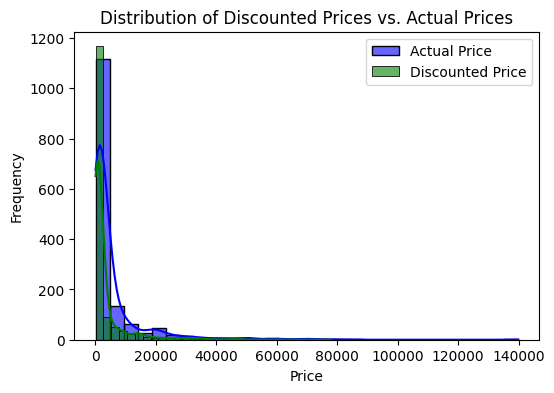

In [132]:
plt.figure(figsize=(6, 4))
sns.histplot(amazon_df['actual_price'], bins=30, label='Actual Price', color='blue', kde=True, alpha=0.6)
sns.histplot(amazon_df['discounted_price'], bins=30, label='Discounted Price', color='green', kde=True, alpha=0.6)
plt.title('Distribution of Discounted Prices vs. Actual Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 4. How does the average discount percentage vary across categories?

In [133]:
average_discount_by_category = amazon_df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)

average_discount_by_category = average_discount_by_category.reset_index()
average_discount_by_category.columns = ['Category', 'Average Discount (%)']

print("Average Discount Percentage by Category:")
average_discount_by_category

Average Discount Percentage by Category:


,Category,Average Discount (%)
0,HomeImprovement,57.500000
1,Computers&Accessories,54.024283
2,Health&PersonalCare,53.000000
3,Electronics,50.828897
4,MusicalInstruments,46.000000
5,Car&Motorbike,42.000000
6,Home&Kitchen,40.120536
7,OfficeProducts,12.354839
8,Toys&Games,0.000000


### 5. What are the most popular product names?

In [134]:
most_popular_products = (
    amazon_df[['product_name', 'rating_count']]
    .sort_values(by='rating_count', ascending=False)
    .head(10)
)

print("Most Popular Product Names:")
most_popular_products

Most Popular Product Names:


,product_name,rating_count
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",313832.0


### 6. What are the most popular product keywords?

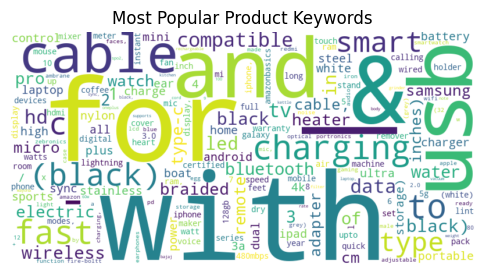

Top Product Keywords:
    Keyword  Frequency
0      with        751
1       for        672
2         |        457
3         &        432
4       usb        377
5       and        330
6     cable        320
7         -        220
8  charging        219
9        to        218


In [138]:
from collections import Counter
from wordcloud import WordCloud

# Tokenizing words in product names and counting occurrences
keywords = ' '.join(amazon_df['product_name'].str.lower())
word_count = Counter(keywords.split())

# Generating a word cloud for visualization
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_count)

# Displaying the word cloud
plt.figure(figsize=(6,4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Popular Product Keywords')
plt.show()

# Displaying top 10 keywords
top_keywords = pd.DataFrame(word_count.most_common(10), columns=['Keyword', 'Frequency'])
print("Top Product Keywords:")
print(top_keywords)

### 7. What are the most popular product reviews?

In [140]:
most_popular_reviews = amazon_df[['product_name', 'review_title', 'rating_count']].sort_values(by='rating_count', ascending=False).head(10)

print("Most Popular Product Reviews:")
most_popular_reviews

Most Popular Product Reviews:


,product_name,review_title,rating_count
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,"It's quite good and value for money,Works well...",426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","It's quite good and value for money,Works well...",426973.0
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","It's quite good and value for money,Works well...",426973.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,"It's quite good and value for money,Works well...",426972.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,"Best value for money,HEAD PHONE POUCH NOT RECE...",363713.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,"Best value for money,HEAD PHONE POUCH NOT RECE...",363713.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,"Best value for money,HEAD PHONE POUCH NOT RECE...",363711.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...","Best phone for below normal use,Good mobile fo...",313836.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...","Best phone for below normal use,Good mobile fo...",313836.0
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...","Best phone for below normal use,Good mobile fo...",313832.0


### 8. What is the correlation between discounted_price and rating?

In [142]:
correlation = amazon_df['discounted_price'].corr(amazon_df['rating'])
print(f"Correlation between Discounted Price and Rating: {correlation}")

Correlation between Discounted Price and Rating: 0.12033741712288534


### 9. What are the Top 5 categories based on the highest ratings?

In [143]:
top_categories_by_rating = amazon_df.groupby('main_category')['rating'].mean().sort_values(ascending=False).head(5)
top_categories_by_rating = top_categories_by_rating.reset_index()
top_categories_by_rating.columns = ['Category', 'Average Rating']

print("Top 5 Categories Based on Highest Ratings:")
top_categories_by_rating

Top 5 Categories Based on Highest Ratings:


,Category,Average Rating
0,OfficeProducts,4.309677
1,Toys&Games,4.300000
2,HomeImprovement,4.250000
3,Computers&Accessories,4.154967
4,Electronics,4.081749


### 10 Identify any potential areas for improvement or optimization based on the data analysis.

In [144]:
low_rated_categories = amazon_df.groupby('main_category')['rating'].mean().sort_values().head(5)
print("Categories with Lowest Average Ratings:")
print(low_rated_categories)
high_price_low_discount = amazon_df[(amazon_df['actual_price'] > amazon_df['actual_price'].median()) &
                               (amazon_df['discount_percentage'] < amazon_df['discount_percentage'].median())]
print("High Price and Low Discount Products:")
high_price_low_discount[['product_name', 'actual_price', 'discount_percentage']].head(10)

Categories with Lowest Average Ratings:
main_category
Car&Motorbike          3.800000
MusicalInstruments     3.900000
Health&PersonalCare    4.000000
Home&Kitchen           4.040716
Electronics            4.081749
Name: rating, dtype: float64
High Price and Low Discount Products:


,product_name,actual_price,discount_percentage
16,MI 80 cm (32 inches) 5A Series HD Ready Smart ...,24999.0,44.0
19,LG 80 cm (32 inches) HD Ready Smart LED TV 32L...,21990.0,39.0
20,Duracell USB Lightning Apple Certified (Mfi) B...,1799.0,46.0
22,Samsung 80 cm (32 Inches) Wondertainment Serie...,22900.0,41.0
24,Acer 80 cm (32 inches) I Series HD Ready Andro...,19990.0,42.0
26,OnePlus 80 cm (32 inches) Y Series HD Ready LE...,19999.0,25.0
38,OnePlus 126 cm (50 inches) Y Series 4K Ultra H...,45999.0,28.0
41,Mi 108 cm (43 inches) Full HD Android LED TV 4...,34999.0,43.0
50,TP-Link AC600 600 Mbps WiFi Wireless Network U...,2199.0,45.0
53,VW 80 cm (32 inches) Frameless Series HD Ready...,12999.0,46.0


# EDA-4 (spotify dataset)

In [145]:
df = pd.read_csv(r'D:\PW\ML\EDA\spotify.csv')

### 1. Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful.

In [146]:
null_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()
if duplicate_rows > 0:
    spotify_data = df.drop_duplicates()

print("Null Values per Column:\n", null_values)
print(f"Number of Duplicate Rows: {duplicate_rows}")

Null Values per Column:
 Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64
Number of Duplicate Rows: 27


### 2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram

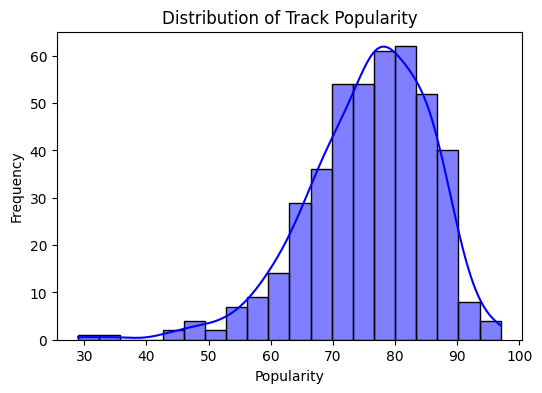

In [148]:
plt.figure(figsize=(6,4))
sns.histplot(df['Popularity'], bins=20, kde=True, color='blue')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

### 3. Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot.

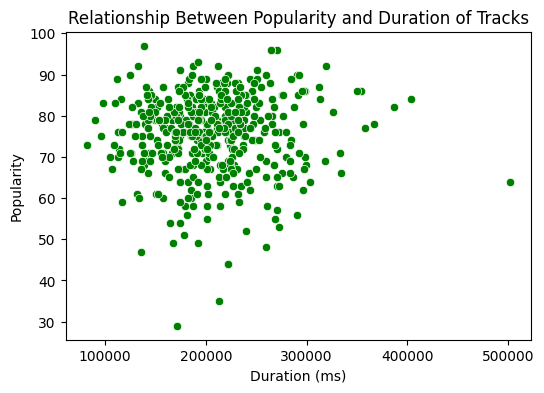

In [149]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['Duration (ms)'], y=df['Popularity'], color='green')
plt.title('Relationship Between Popularity and Duration of Tracks')
plt.xlabel('Duration (ms)')
plt.ylabel('Popularity')
plt.show()

### 4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot

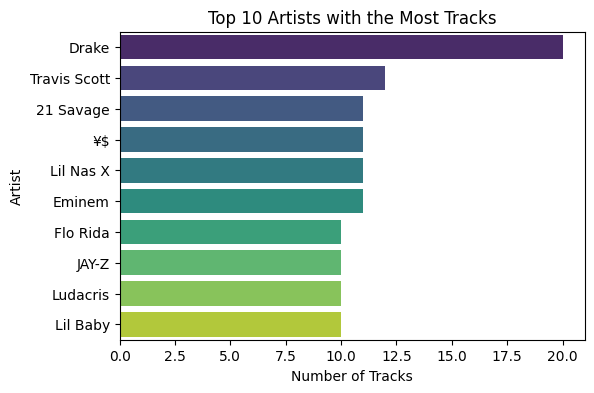

Artist with Most Tracks: Drake (20 tracks)


In [150]:
top_artists = df['Artist'].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(y=df['Artist'],
              order=df['Artist'].value_counts().head(10).index,
              palette='viridis')
plt.title('Top 10 Artists with the Most Tracks')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.show()

# Displaying the artist with the highest number of tracks
most_tracks_artist = top_artists.idxmax()
most_tracks_count = top_artists.max()
print(f"Artist with Most Tracks: {most_tracks_artist} ({most_tracks_count} tracks)")


### 5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.

In [151]:
least_popular_tracks = df.nsmallest(5, 'Popularity')[['Artist', 'Track Name', 'Popularity']]
print("Top 5 Least Popular Tracks:\n", least_popular_tracks)

Top 5 Least Popular Tracks:
              Artist                     Track Name  Popularity
207          Pressa  Attachments (feat. Coi Leray)          29
231   Justin Bieber                     Intentions          35
413  French Montana                Splash Brothers          44
435  French Montana                Splash Brothers          44
225        Lil Baby                  On Me - Remix          47


### 6. Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist.

In [152]:
top_5_artists = df['Artist'].value_counts().head(5).index

average_popularity_top_artists = (
    df[df['Artist'].isin(top_5_artists)]
    .groupby('Artist')['Popularity']
    .mean()
    .sort_values(ascending=False)
)

print("Average Popularity for Top 5 Most Popular Artists:\n", average_popularity_top_artists)

Average Popularity for Top 5 Most Popular Artists:
 Artist
Travis Scott    87.000000
¥$              86.090909
21 Savage       84.181818
Drake           83.500000
Lil Nas X       76.090909
Name: Popularity, dtype: float64


### 7. .For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist.

In [153]:
most_popular_tracks_top_artists = (
    df[df['Artist'].isin(top_5_artists)]
    .sort_values(by=['Artist', 'Popularity'], ascending=[True, False])
    .groupby('Artist')
    .first()
)[['Track Name', 'Popularity']]

print("Most Popular Tracks for Top 5 Artists:\n", most_popular_tracks_top_artists)


Most Popular Tracks for Top 5 Artists:
                                            Track Name  Popularity
Artist                                                           
21 Savage                                      redrum          96
Drake         Rich Baby Daddy (feat. Sexyy Red & SZA)          92
Lil Nas X                           THATS WHAT I WANT          81
Travis Scott               FE!N (feat. Playboi Carti)          93
¥$                                           CARNIVAL          96


### 8. Visualize relationships between multiple numerical variables simultaneously using a pair plot.

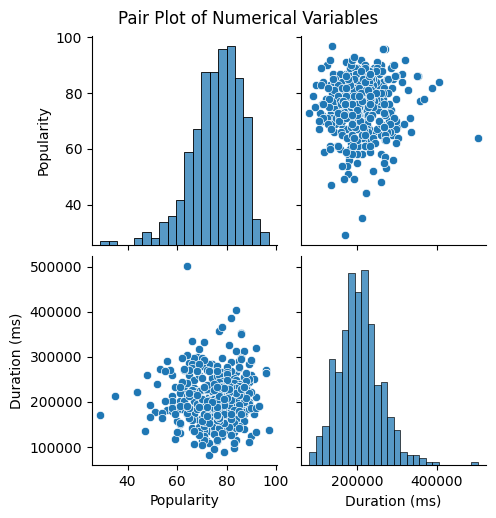

In [154]:
sns.pairplot(df[['Popularity', 'Duration (ms)']])
plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
plt.show()

### 9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot.

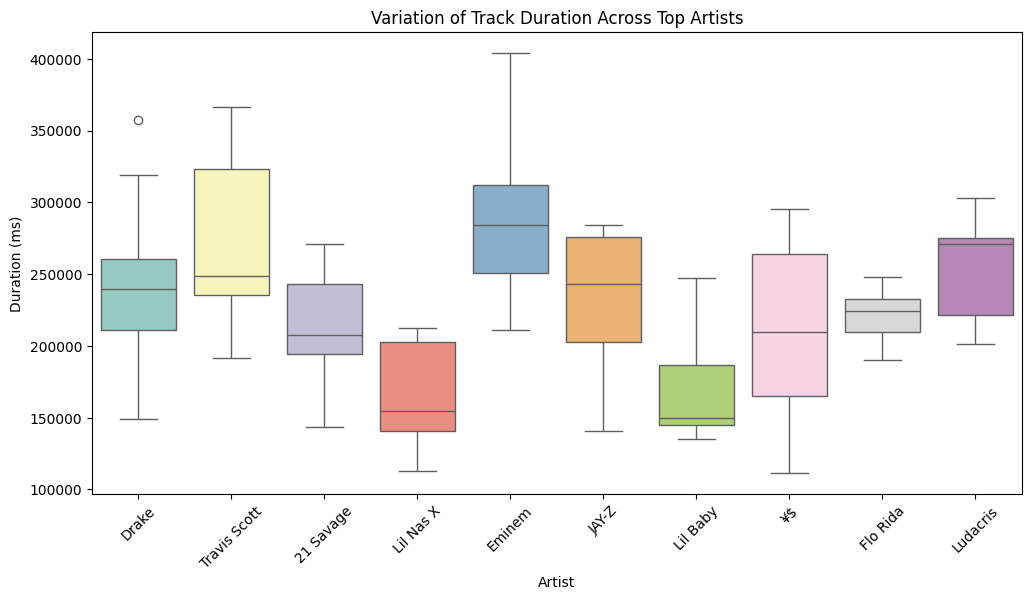

In [156]:
top_10_artists = df['Artist'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Artist', y='Duration (ms)',
            data=df[df['Artist'].isin(top_10_artists)],
            palette='Set3')
plt.title('Variation of Track Duration Across Top Artists')
plt.xlabel('Artist')
plt.ylabel('Duration (ms)')
plt.xticks(rotation=45)
plt.show()


### 10 How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot.

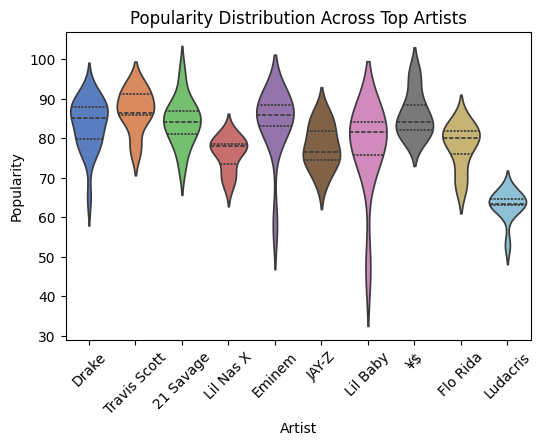

In [157]:
plt.figure(figsize=(6, 4))
sns.violinplot(x='Artist', y='Popularity',
               data=df[df['Artist'].isin(top_10_artists)],
               inner='quartile', palette='muted')
plt.title('Popularity Distribution Across Top Artists')
plt.xlabel('Artist')
plt.ylabel('Popularity')
plt.xticks(rotation=45)
plt.show()
